# Notebook 03: Advanced EDA & Anomaly Detection
## Weather Trend Forecasting — PM Accelerator Assessment
### Goal: Detect anomalies using Isolation Forest & LOF, perform time series decomposition

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PROCESSED_DATA = Path('../data/processed/weather_cleaned.csv')
FIGURES_DIR = Path('../outputs/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DATA, parse_dates=['last_updated'])
print(f"Loaded: {df.shape}")

Loaded: (144822, 39)


## 1. Time Series Decomposition

Daily time series: 747 days
From 2024-05-16 00:00:00 to 2026-06-01 00:00:00


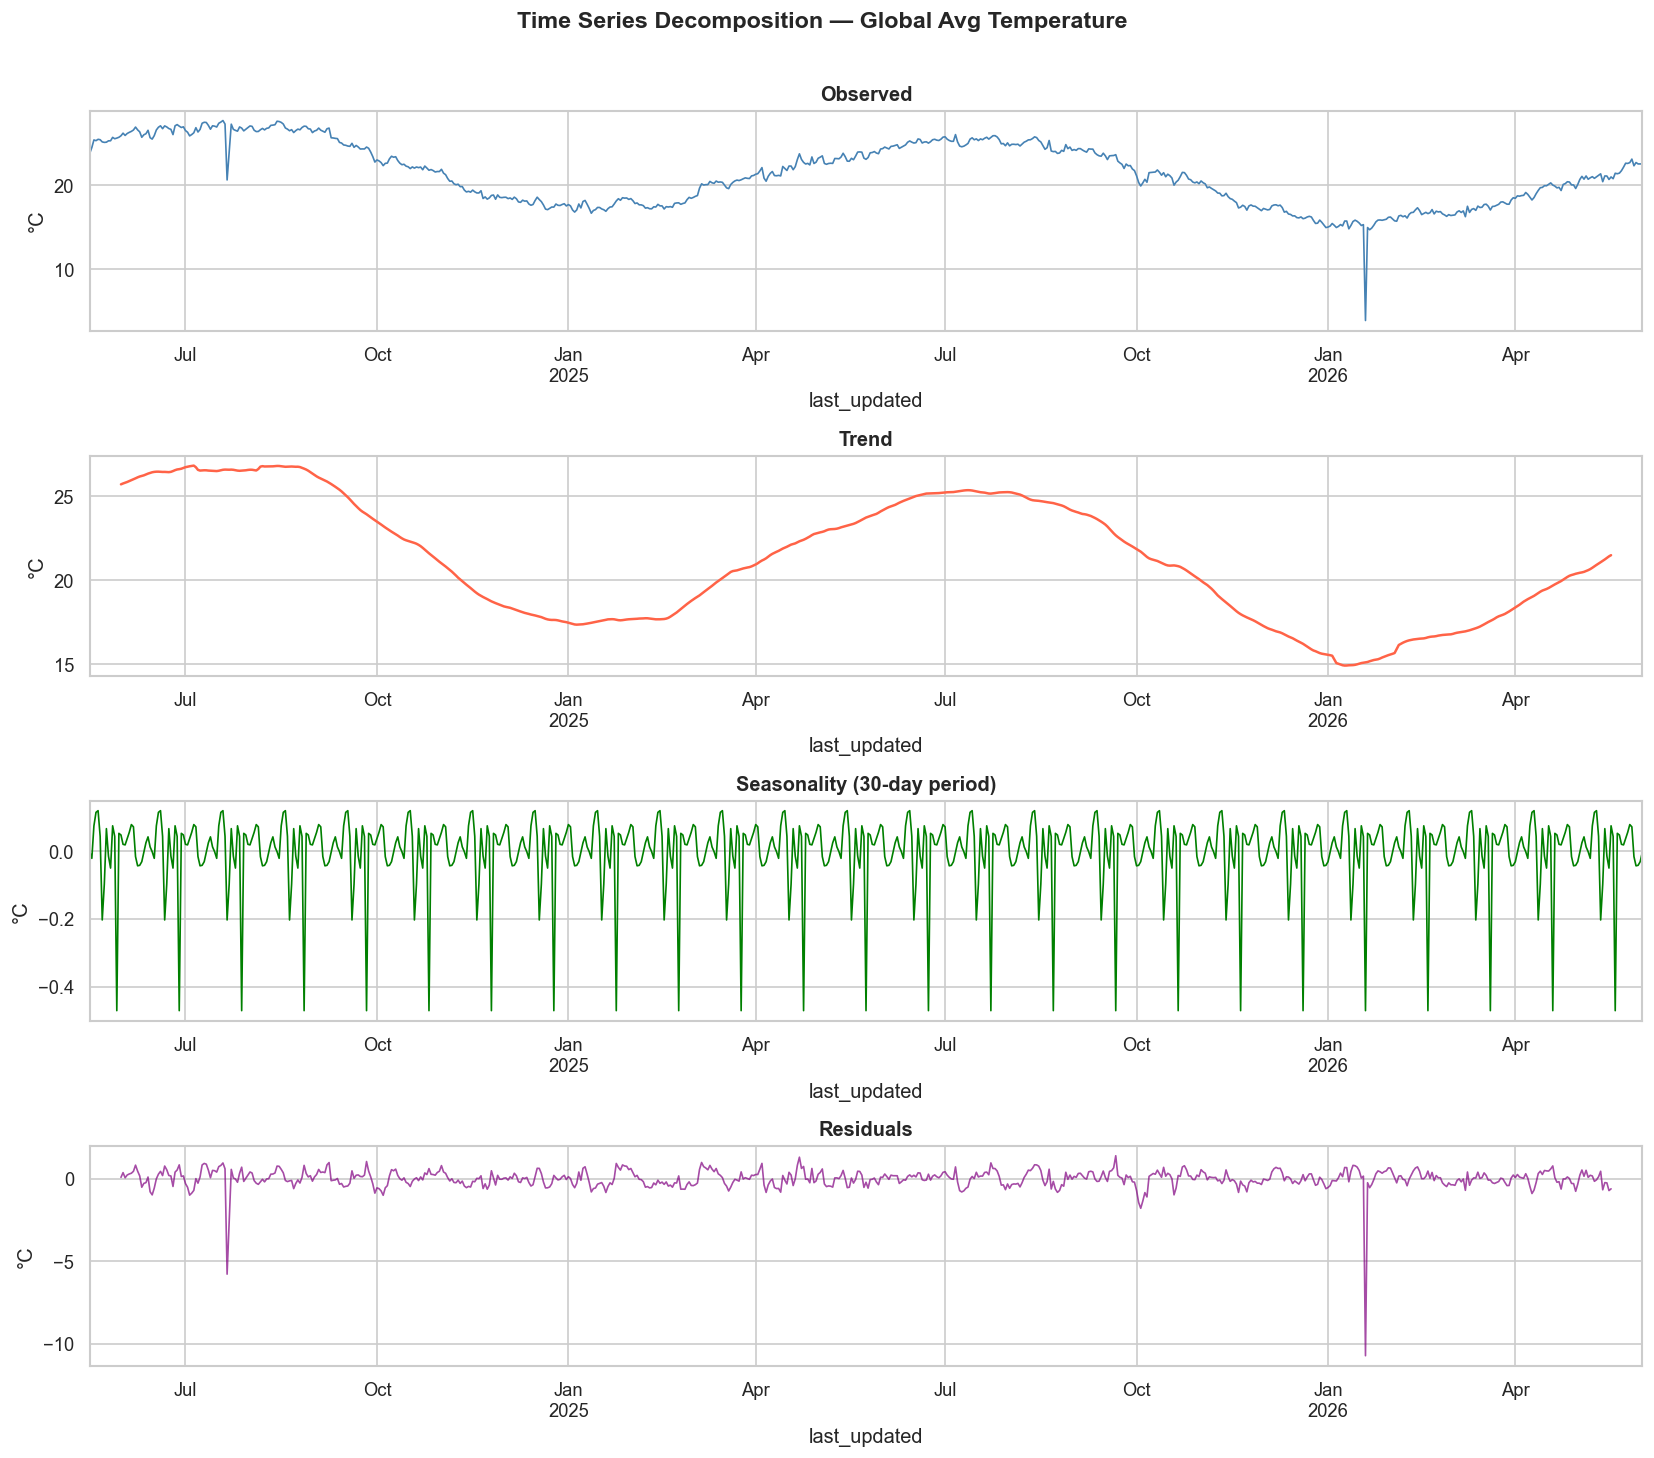

 Saved: 12_time_series_decomposition.png


In [12]:
# Resample to daily global average temperature
daily_temp = df.groupby(df['last_updated'].dt.date)['temperature_celsius'].mean()
daily_temp.index = pd.to_datetime(daily_temp.index)
daily_temp = daily_temp.asfreq('D').interpolate()

print(f"Daily time series: {len(daily_temp)} days")
print(f"From {daily_temp.index.min()} to {daily_temp.index.max()}")

# Decompose
decomposition = seasonal_decompose(daily_temp, model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
decomposition.observed.plot(ax=axes[0], color='steelblue', linewidth=1)
axes[0].set_title('Observed', fontweight='bold')
axes[0].set_ylabel('°C')

decomposition.trend.plot(ax=axes[1], color='tomato', linewidth=1.5)
axes[1].set_title('Trend', fontweight='bold')
axes[1].set_ylabel('°C')

decomposition.seasonal.plot(ax=axes[2], color='green', linewidth=1)
axes[2].set_title('Seasonality (30-day period)', fontweight='bold')
axes[2].set_ylabel('°C')

decomposition.resid.plot(ax=axes[3], color='purple', linewidth=1, alpha=0.7)
axes[3].set_title('Residuals', fontweight='bold')
axes[3].set_ylabel('°C')

plt.suptitle('Time Series Decomposition — Global Avg Temperature',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '12_time_series_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 12_time_series_decomposition.png")

## 2. Rolling Statistics

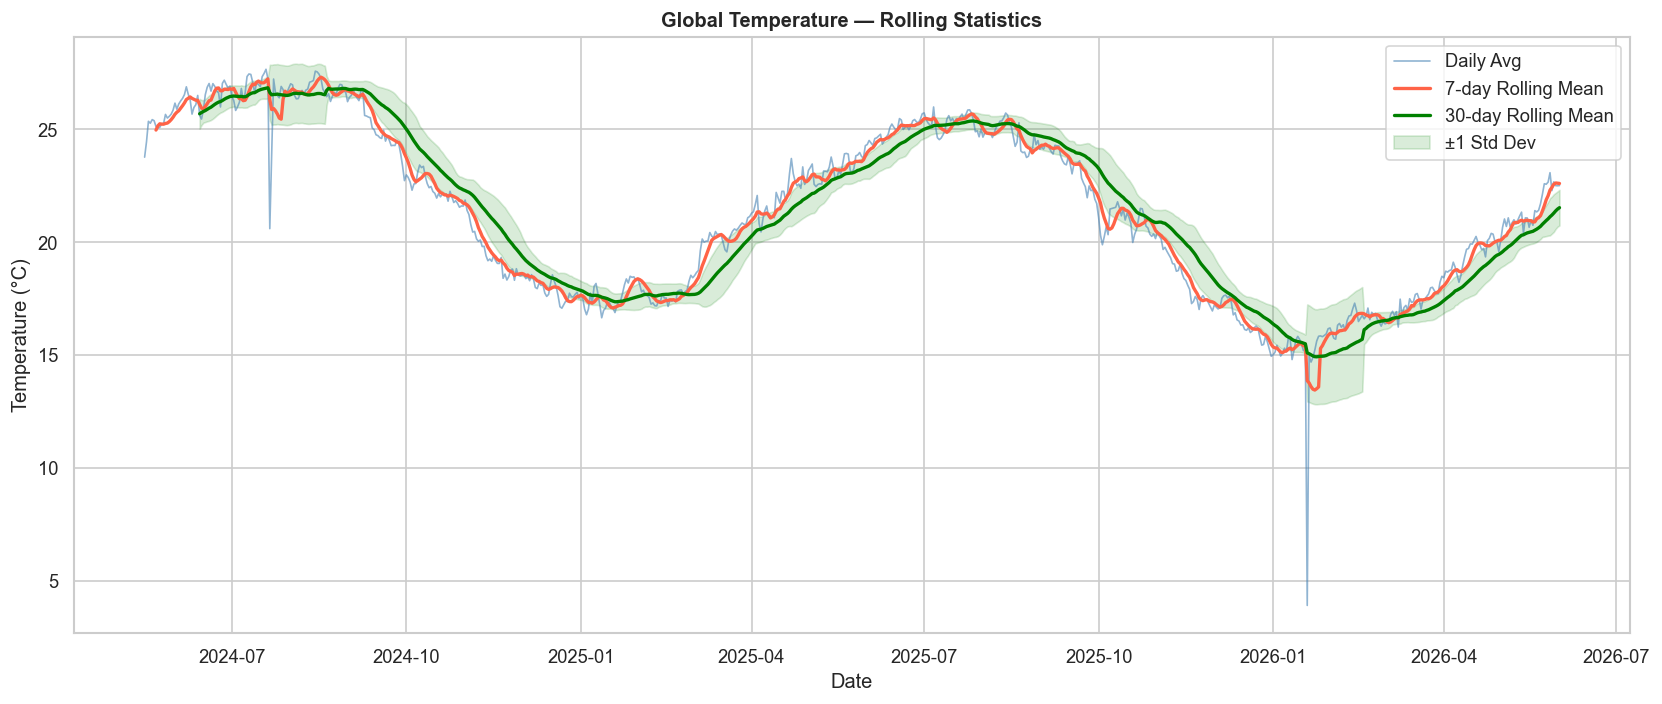

 Saved: 13_rolling_statistics.png


In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(daily_temp.index, daily_temp.values,
        color='steelblue', linewidth=1, alpha=0.6, label='Daily Avg')
ax.plot(daily_temp.index, daily_temp.rolling(7).mean(),
        color='tomato', linewidth=2, label='7-day Rolling Mean')
ax.plot(daily_temp.index, daily_temp.rolling(30).mean(),
        color='green', linewidth=2, label='30-day Rolling Mean')

# Rolling std band
rolling_mean = daily_temp.rolling(30).mean()
rolling_std = daily_temp.rolling(30).std()
ax.fill_between(daily_temp.index,
                rolling_mean - rolling_std,
                rolling_mean + rolling_std,
                alpha=0.15, color='green', label='±1 Std Dev')

ax.set_title('Global Temperature — Rolling Statistics', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '13_rolling_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 13_rolling_statistics.png")

## 3. Anomaly Detection — Isolation Forest

In [14]:
# Features for anomaly detection
anomaly_features = [
    'temperature_celsius', 'humidity', 'pressure_mb',
    'wind_kph', 'precip_mm', 'visibility_km',
    'air_quality_PM2.5', 'air_quality_PM10'
]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[anomaly_features].fillna(0))

# Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.03,  # assume 3% anomalies
    random_state=42,
    n_jobs=-1
)
df['anomaly_iso'] = iso_forest.fit_predict(X_scaled)
df['anomaly_iso_label'] = df['anomaly_iso'].map({1: 'Normal', -1: 'Anomaly'})

n_anomalies = (df['anomaly_iso'] == -1).sum()
print(f"Isolation Forest complete")
print(f"Anomalies detected: {n_anomalies:,} ({n_anomalies/len(df)*100:.1f}%)")
print(df['anomaly_iso_label'].value_counts())

Isolation Forest complete
Anomalies detected: 4,345 (3.0%)
anomaly_iso_label
Normal     140477
Anomaly      4345
Name: count, dtype: int64


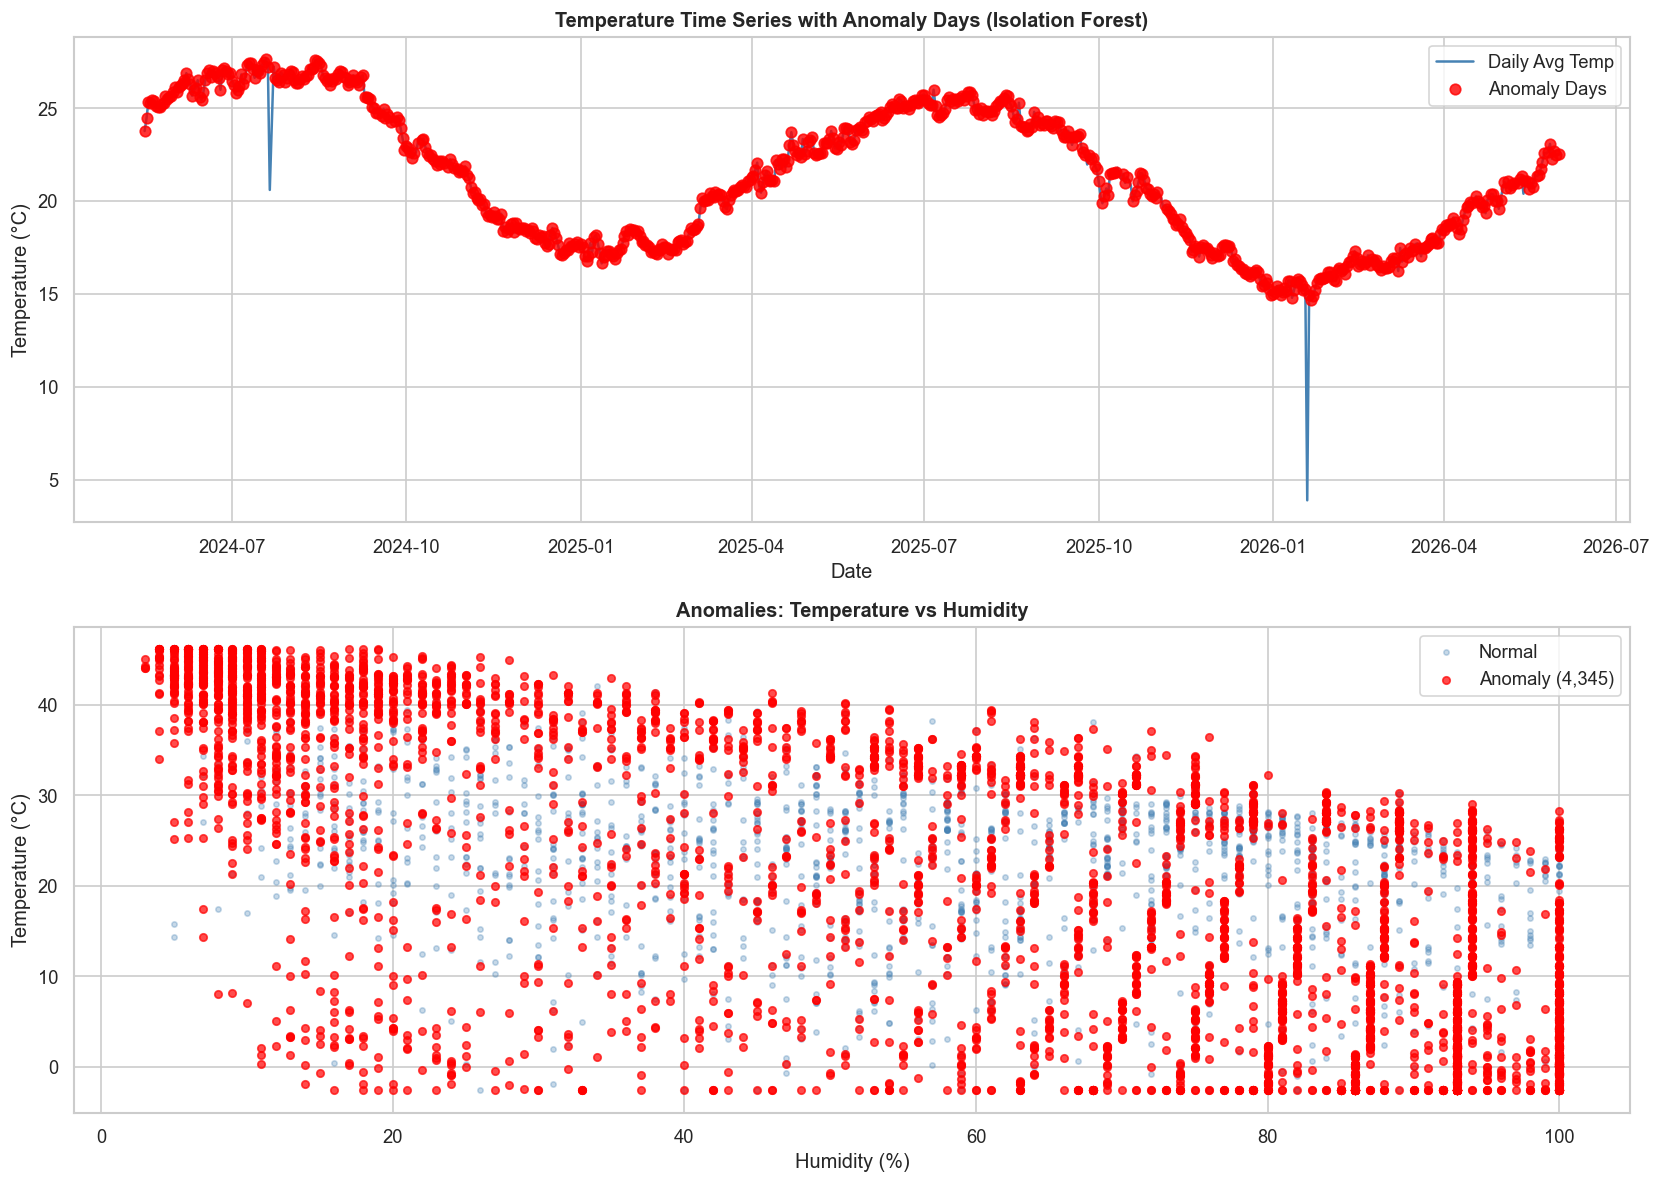

Saved: 14_isolation_forest_anomalies.png


In [15]:
# Visualize anomalies on temperature time series
daily_anomaly = df.groupby(df['last_updated'].dt.date).agg(
    temp_mean=('temperature_celsius', 'mean'),
    anomaly_count=('anomaly_iso', lambda x: (x == -1).sum())
).reset_index()
daily_anomaly['last_updated'] = pd.to_datetime(daily_anomaly['last_updated'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Temperature with anomaly days highlighted
axes[0].plot(daily_anomaly['last_updated'], daily_anomaly['temp_mean'],
             color='steelblue', linewidth=1.5, label='Daily Avg Temp')
anomaly_days = daily_anomaly[daily_anomaly['anomaly_count'] > 0]
axes[0].scatter(anomaly_days['last_updated'], anomaly_days['temp_mean'],
                color='red', zorder=5, s=40, label='Anomaly Days', alpha=0.8)
axes[0].set_title('Temperature Time Series with Anomaly Days (Isolation Forest)',
                   fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()

# Scatter: Temperature vs Humidity colored by anomaly
normal = df[df['anomaly_iso_label'] == 'Normal'].sample(3000, random_state=42)
anomalies = df[df['anomaly_iso_label'] == 'Anomaly']
axes[1].scatter(normal['humidity'], normal['temperature_celsius'],
                c='steelblue', alpha=0.3, s=10, label='Normal')
axes[1].scatter(anomalies['humidity'], anomalies['temperature_celsius'],
                c='red', alpha=0.7, s=20, label=f'Anomaly ({len(anomalies):,})')
axes[1].set_title('Anomalies: Temperature vs Humidity', fontweight='bold')
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '14_isolation_forest_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 14_isolation_forest_anomalies.png")

## 4. Anomaly Detection — Local Outlier Factor (LOF)

In [16]:
# LOF on a sample (LOF is slow on 144k rows)
sample_idx = df.sample(20000, random_state=42).index
X_sample = X_scaled[df.index.isin(sample_idx)]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.03, n_jobs=-1)
lof_labels = lof.fit_predict(X_sample)

df.loc[df.index.isin(sample_idx), 'anomaly_lof'] = lof_labels
df['anomaly_lof_label'] = df['anomaly_lof'].map({1.0: 'Normal', -1.0: 'Anomaly'})

n_lof = (df['anomaly_lof'] == -1).sum()
print(f"LOF complete")
print(f"LOF Anomalies detected: {n_lof:,} ({n_lof/20000*100:.1f}% of sample)")

LOF complete
LOF Anomalies detected: 600 (3.0% of sample)


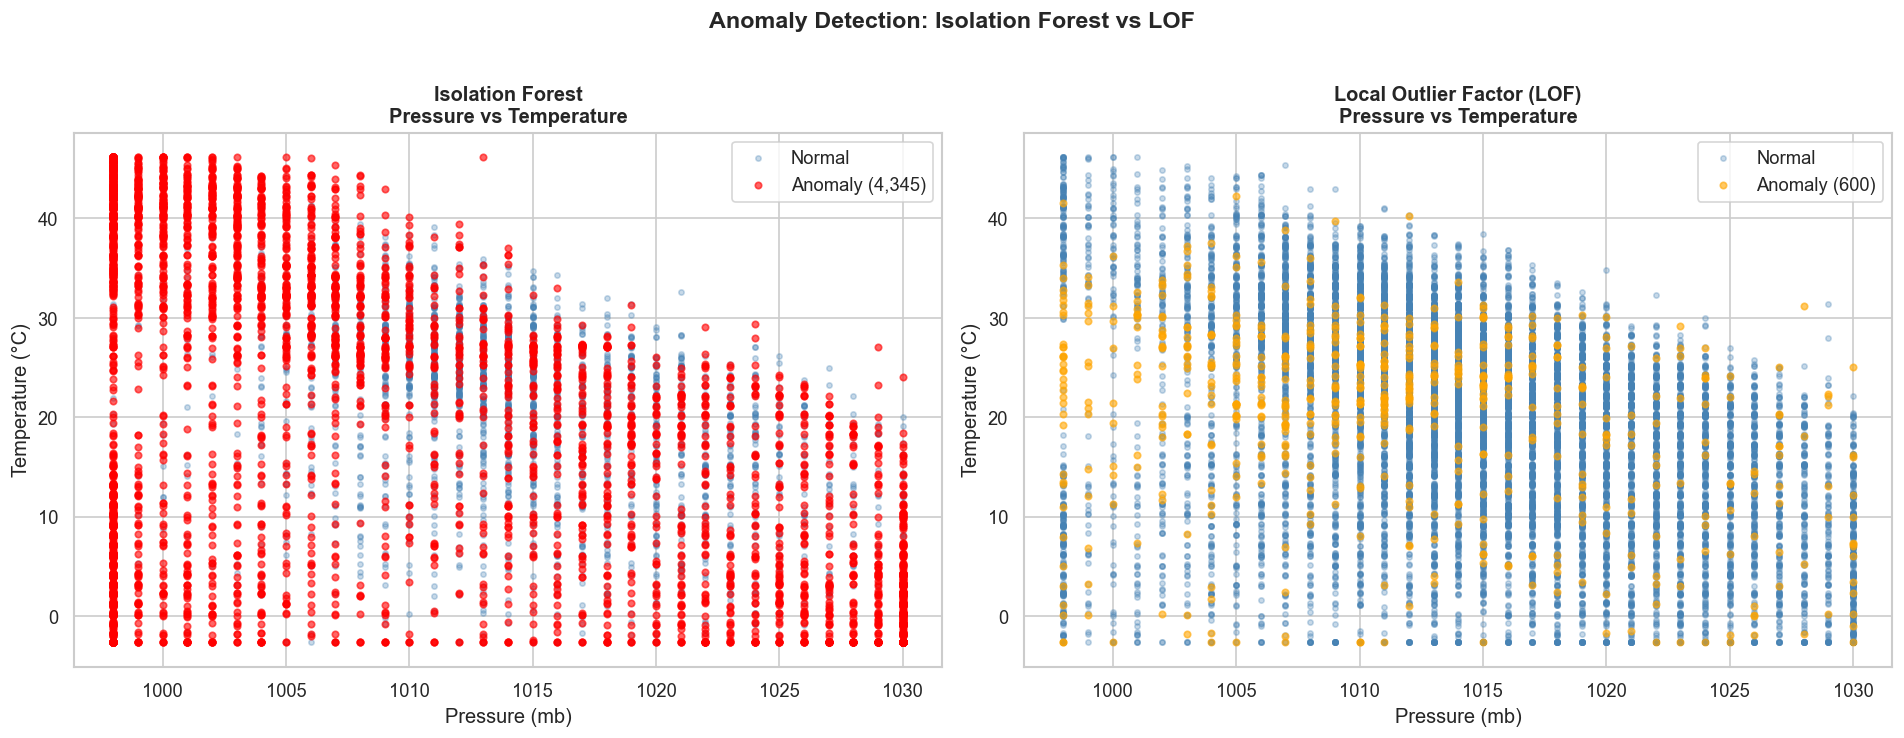

 Saved: 15_anomaly_comparison.png


In [17]:
# Compare Isolation Forest vs LOF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Isolation Forest
normal_iso = df[df['anomaly_iso_label'] == 'Normal'].sample(3000, random_state=42)
anom_iso = df[df['anomaly_iso_label'] == 'Anomaly']
axes[0].scatter(normal_iso['pressure_mb'], normal_iso['temperature_celsius'],
                c='steelblue', alpha=0.3, s=10, label='Normal')
axes[0].scatter(anom_iso['pressure_mb'], anom_iso['temperature_celsius'],
                c='red', alpha=0.6, s=15, label=f'Anomaly ({len(anom_iso):,})')
axes[0].set_title('Isolation Forest\nPressure vs Temperature', fontweight='bold')
axes[0].set_xlabel('Pressure (mb)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()

# LOF
lof_sample = df[df['anomaly_lof'].notna()]
normal_lof = lof_sample[lof_sample['anomaly_lof_label'] == 'Normal']
anom_lof = lof_sample[lof_sample['anomaly_lof_label'] == 'Anomaly']
axes[1].scatter(normal_lof['pressure_mb'], normal_lof['temperature_celsius'],
                c='steelblue', alpha=0.3, s=10, label='Normal')
axes[1].scatter(anom_lof['pressure_mb'], anom_lof['temperature_celsius'],
                c='orange', alpha=0.6, s=15, label=f'Anomaly ({len(anom_lof):,})')
axes[1].set_title('Local Outlier Factor (LOF)\nPressure vs Temperature', fontweight='bold')
axes[1].set_xlabel('Pressure (mb)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].legend()

plt.suptitle('Anomaly Detection: Isolation Forest vs LOF', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '15_anomaly_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: 15_anomaly_comparison.png")

## 5. Anomaly Profile Analysis

ANOMALY PROFILE vs NORMAL OBSERVATIONS
                      Normal  Anomaly
temperature_celsius    21.37    20.51
humidity               67.06    58.05
pressure_mb          1014.19  1009.15
wind_kph               12.54    18.66
precip_mm               0.01     0.03
air_quality_PM2.5      19.08    38.04


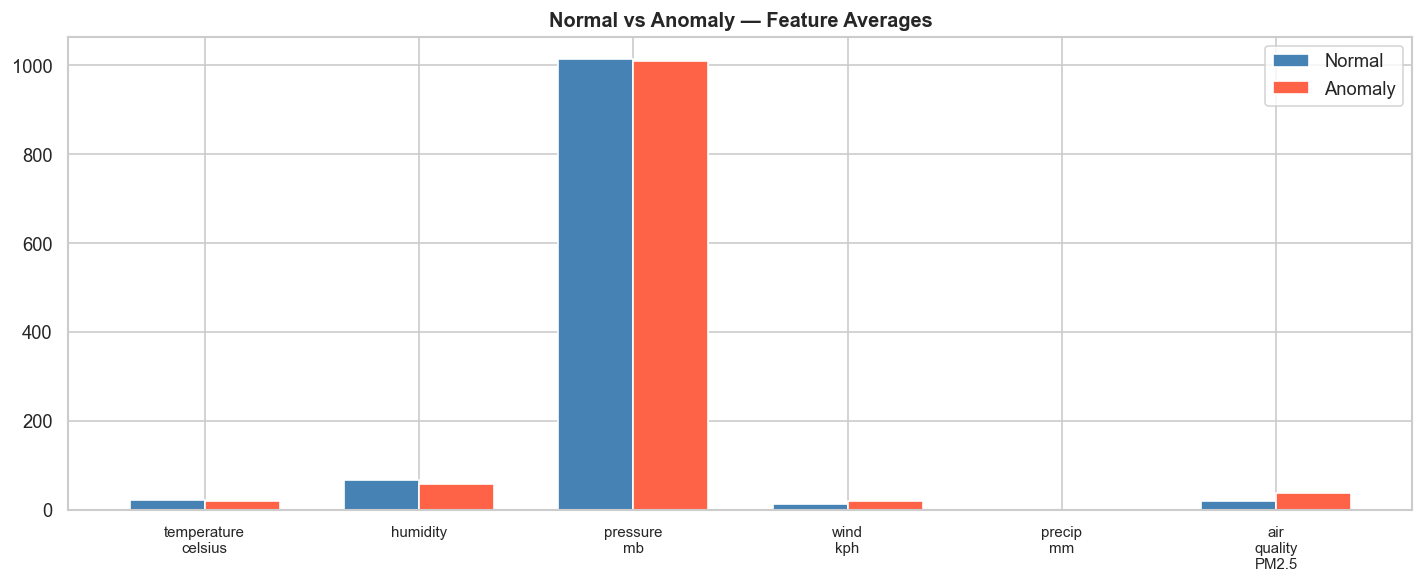

Saved: 16_anomaly_profile.png


In [18]:
# What do anomalies look like vs normal observations?
compare_cols = ['temperature_celsius', 'humidity', 'pressure_mb',
                'wind_kph', 'precip_mm', 'air_quality_PM2.5']

normal_profile = df[df['anomaly_iso_label'] == 'Normal'][compare_cols].mean()
anomaly_profile = df[df['anomaly_iso_label'] == 'Anomaly'][compare_cols].mean()

profile_df = pd.DataFrame({
    'Normal': normal_profile,
    'Anomaly': anomaly_profile
})

print("ANOMALY PROFILE vs NORMAL OBSERVATIONS")
print(profile_df.round(2))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(compare_cols))
width = 0.35
bars1 = ax.bar(x - width/2, normal_profile, width,
               label='Normal', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, anomaly_profile, width,
               label='Anomaly', color='tomato', edgecolor='white')
ax.set_title('Normal vs Anomaly — Feature Averages', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('_', '\n') for c in compare_cols], fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '16_anomaly_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 16_anomaly_profile.png")

## 6. Anomaly Distribution by Continent

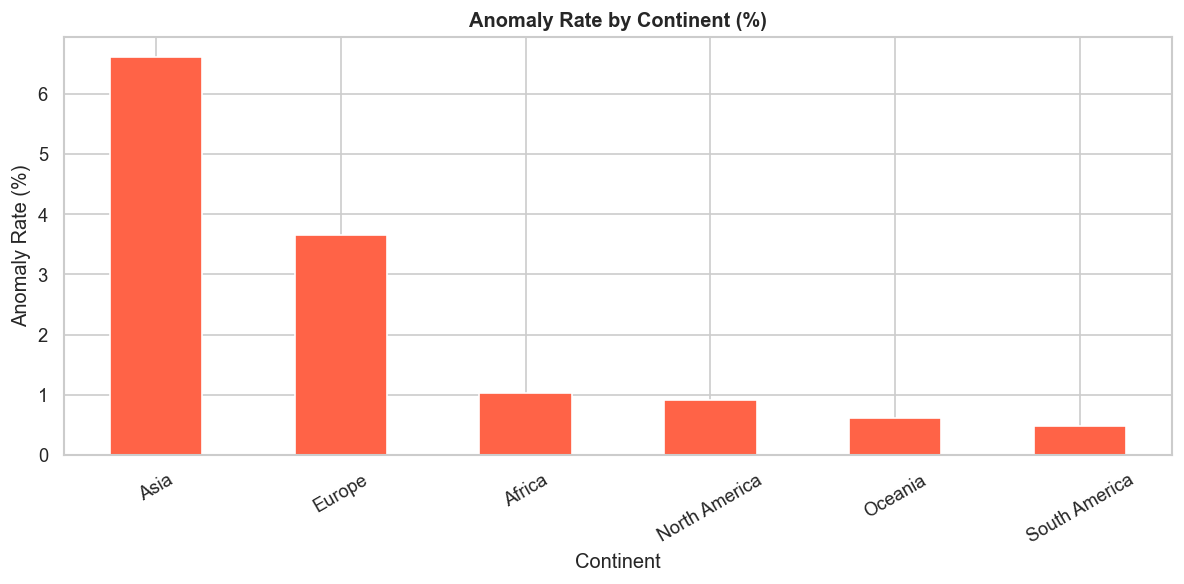

Saved: 17_anomaly_by_continent.png


In [19]:
continent_anomaly = df.groupby('continent').apply(
    lambda x: (x['anomaly_iso'] == -1).sum() / len(x) * 100
).sort_values(ascending=False).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
continent_anomaly.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Anomaly Rate by Continent (%)', fontweight='bold')
ax.set_xlabel('Continent')
ax.set_ylabel('Anomaly Rate (%)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '17_anomaly_by_continent.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 17_anomaly_by_continent.png")

In [20]:
# Save dataset with anomaly labels for use in later notebooks
enriched_path = Path('../data/processed/weather_with_anomalies.csv')
df.to_csv(enriched_path, index=False)
print(f"Enriched dataset saved: {enriched_path}")
print(f"Shape: {df.shape}")

Enriched dataset saved: ..\data\processed\weather_with_anomalies.csv
Shape: (144822, 43)
